# Systematic Strategy Backtesting
## 1. Momentum Strategy

In [20]:
# On importe ce dont on a besoin 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [21]:
# On télécharge les data (on prend le Cac40 ici ^FCHI ou alors le S&P500 SPY)

ticker = "^FCHI"
start = "2020-01-01"
end = "2026-01-01"

data = yf.download(ticker, start=start, end=end)
close = data["Close"]

print(f"Data downloaded : {len(close)} days")
print(f"From : {close.index[0].date()}")
print(f"To   : {close.index[-1].date()}")
close.tail()

[*********************100%***********************]  1 of 1 completed

Data downloaded : 1538 days
From : 2020-01-02
To   : 2025-12-31


Ticker,^FCHI
Date,
2025-12-23,8103.850098
2025-12-24,8103.580078
2025-12-29,8112.020020
2025-12-30,8168.149902
2025-12-31,8149.500000


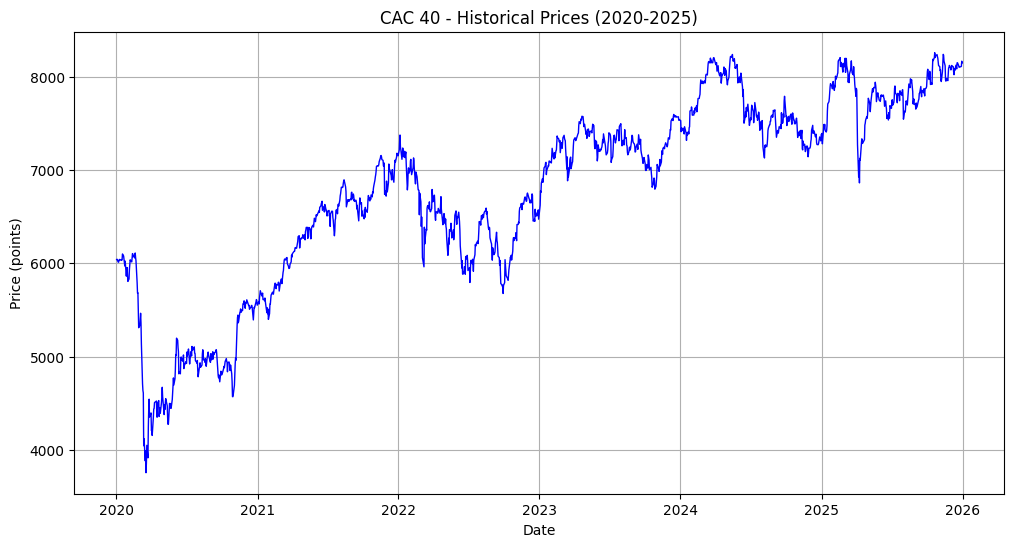

In [22]:
# graph pour visualiser : 

plt.figure(figsize=(12, 6))
plt.plot(close, color="blue", linewidth=1)
plt.title("CAC 40 - Historical Prices (2020-2025)")
plt.xlabel("Date")
plt.ylabel("Price (points)")
plt.grid(True)
plt.show()

In [23]:
# On code la stratégie de momentum : 

short_window = 20 
long_window = 50 

# On calcule les mouvements moyens 

signals = pd.DataFrame(index=close.index)
signals["price"] = close
signals["MA20"] = close.rolling(window=short_window).mean()
signals["MA50"] = close.rolling(window=long_window).mean()

# On génére un signal  1 = buy, 0 0 sell

signals["signal"] = 0 
signals.loc[signals["MA20"] > signals["MA50"], "signal"] = 1
signals.loc[signals["MA20"] < signals["MA50"], "signal"] = 0

print(f"Buy signals  : {signals['signal'].sum():.0f} days")
print(f"Sell signals : {(signals['signal'] == 0).sum():.0f} days")

Buy signals  : 904 days
Sell signals : 634 days


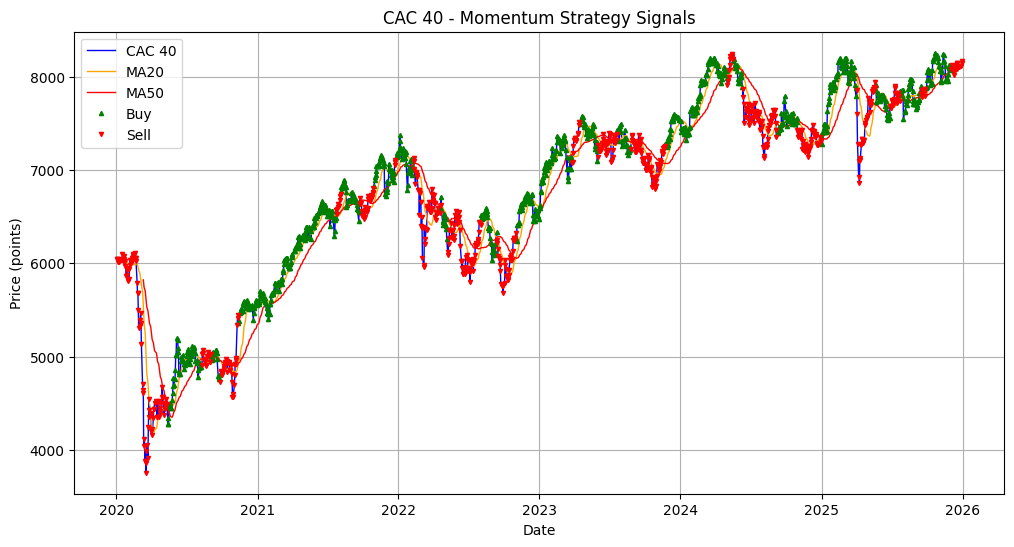

In [24]:
# visualisation : 

plt.figure(figsize=(12, 6))
plt.plot(signals["price"], color="blue", linewidth=1, label="CAC 40")
plt.plot(signals["MA20"], color="orange", linewidth=1, label="MA20")
plt.plot(signals["MA50"], color="red", linewidth=1, label="MA50")

# Buy signals
plt.plot(signals[signals["signal"] == 1].index,
         signals["price"][signals["signal"] == 1],
         "^", markersize=3, color="green", label="Buy")

# Sell signals
plt.plot(signals[signals["signal"] == 0].index,
         signals["price"][signals["signal"] == 0],
         "v", markersize=3, color="red", label="Sell")

plt.title("CAC 40 - Momentum Strategy Signals")
plt.xlabel("Date")
plt.ylabel("Price (points)")
plt.legend()
plt.grid(True)
plt.show()

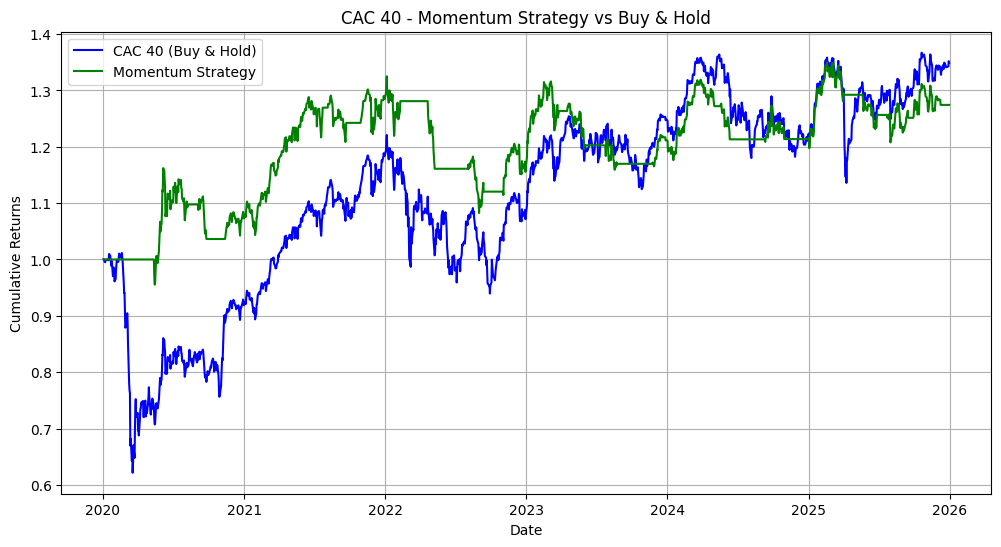

In [25]:
# On calcule les daily returns
signals["returns"] = signals["price"].pct_change()

# Strategy returns (on est investi seulement quand signal = 1)
signals["strategy_returns"] = signals["returns"] * signals["signal"].shift(1)

# Cumulative returns
signals["cumulative_market"] = (1 + signals["returns"]).cumprod()
signals["cumulative_strategy"] = (1 + signals["strategy_returns"]).cumprod()

# graph
plt.figure(figsize=(12, 6))
plt.plot(signals["cumulative_market"], color="blue", label="CAC 40 (Buy & Hold)")
plt.plot(signals["cumulative_strategy"], color="green", label="Momentum Strategy")
plt.title("CAC 40 - Momentum Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# On calcule des métriques : 

# Sharpe Ratio
sharpe_market = (signals["returns"].mean() / signals["returns"].std()) * np.sqrt(252)
sharpe_strategy = (signals["strategy_returns"].mean() / signals["strategy_returns"].std()) * np.sqrt(252)

# Max Drawdown
def max_drawdown(cumulative_returns):
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    return drawdown.min()

mdd_market = max_drawdown(signals["cumulative_market"])
mdd_strategy = max_drawdown(signals["cumulative_strategy"])

# Total Return
total_market = signals["cumulative_market"].iloc[-1] - 1
total_strategy = signals["cumulative_strategy"].iloc[-1] - 1

print("=" * 50)
print("         BACKTESTING SUMMARY")
print("=" * 50)
print(f"{'Metric':<25} {'Market':>10} {'Strategy':>10}")
print("-" * 50)
print(f"{'Total Return':<25} {total_market*100:>9.2f}% {total_strategy*100:>9.2f}%")
print(f"{'Sharpe Ratio':<25} {sharpe_market:>10.2f} {sharpe_strategy:>10.2f}")
print(f"{'Max Drawdown':<25} {mdd_market*100:>9.2f}% {mdd_strategy*100:>9.2f}%")
print("=" * 50)

         BACKTESTING SUMMARY
Metric                        Market   Strategy
--------------------------------------------------
Total Return                  34.89%     27.44%
Sharpe Ratio                    0.35       0.40
Max Drawdown                 -38.56%    -18.31%


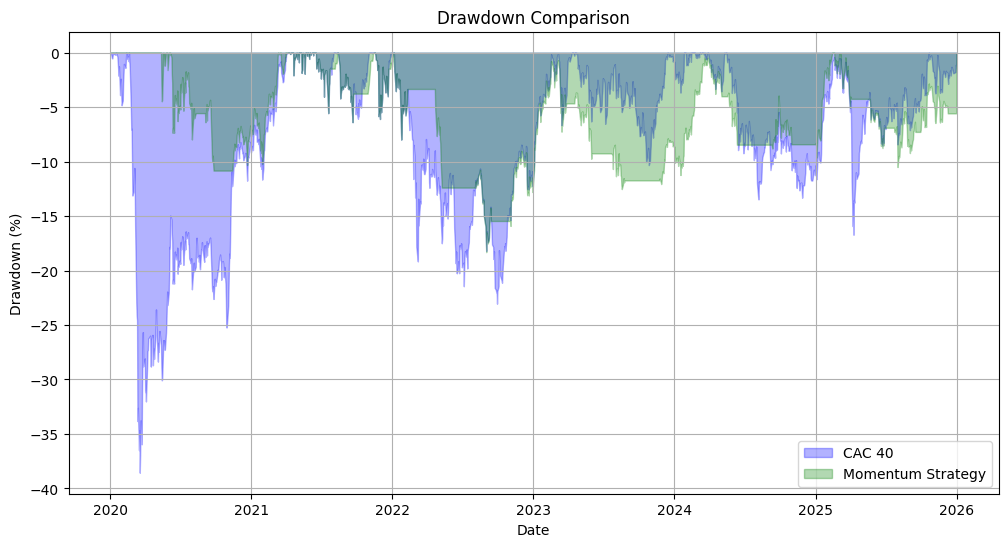

In [27]:
# Info sur le drawdown : 

# Calculate drawdowns
drawdown_market = (signals["cumulative_market"] - signals["cumulative_market"].cummax()) / signals["cumulative_market"].cummax()
drawdown_strategy = (signals["cumulative_strategy"] - signals["cumulative_strategy"].cummax()) / signals["cumulative_strategy"].cummax()

plt.figure(figsize=(12, 6))
plt.fill_between(signals.index, drawdown_market * 100, 0, color="blue", alpha=0.3, label="CAC 40")
plt.fill_between(signals.index, drawdown_strategy * 100, 0, color="green", alpha=0.3, label="Momentum Strategy")
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Résumé final de ce qu'on obtient : 

print("=" * 50)
print("      MOMENTUM STRATEGY - FINAL SUMMARY")
print("=" * 50)
print(f"Asset          : CAC 40")
print(f"Period         : 2020 - 2025")
print(f"Short MA       : {short_window} days")
print(f"Long MA        : {long_window} days")
print("-" * 50)
print(f"{'Metric':<25} {'Market':>10} {'Strategy':>10}")
print("-" * 50)
print(f"{'Total Return':<25} {total_market*100:>9.2f}% {total_strategy*100:>9.2f}%")
print(f"{'Sharpe Ratio':<25} {sharpe_market:>10.2f} {sharpe_strategy:>10.2f}")
print(f"{'Max Drawdown':<25} {mdd_market*100:>9.2f}% {mdd_strategy*100:>9.2f}%")
print(f"{'Buy signals':<25} {signals['signal'].sum():>10.0f} days")
print("=" * 50)
print("Strategy: Buy when MA20 > MA50, Sell otherwise")
print("=" * 50)



      MOMENTUM STRATEGY - FINAL SUMMARY
Asset          : CAC 40
Period         : 2020 - 2025
Short MA       : 20 days
Long MA        : 50 days
--------------------------------------------------
Metric                        Market   Strategy
--------------------------------------------------
Total Return                  34.89%     27.44%
Sharpe Ratio                    0.35       0.40
Max Drawdown                 -38.56%    -18.31%
Buy signals                      904 days
Strategy: Buy when MA20 > MA50, Sell otherwise
